In [7]:
from sklearn.datasets import fetch_california_housing
import numpy as np
import copy
import torch
from sklearn.model_selection import train_test_split
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
torch.manual_seed(0)
np.random.seed(0)

data = fetch_california_housing()
print(data.feature_names)
 
X, y = data.data, data.target

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [8]:
# train-test split of the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, shuffle=True)
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(dataset = train_dataset, batch_size = 3000, shuffle=True) 

In [9]:
# Define the model
class NeuralNetwork(nn.Module):
    def __init__(self, K=100):
        super().__init__()
        self.K = K
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(8, 24), # eight inputs
            nn.ReLU(),
            nn.Linear(24, 12),
            nn.ReLU(),
            nn.Linear(12, 6),
            nn.ReLU(),
            nn.Linear(6, 1) # one output
        )
        
    def f1(self, x):
        s = self.linear_relu_stack(x)
        return s.sum()

    def f2(self, x):
        n = x.shape[0]
        sx = torch.rand(self.K, x.shape[1])
        s = self.linear_relu_stack(sx)
        return -s/self.K1
        
    def forward(self, x):
        output = self.linear_relu_stack(x)
        return output

model = NeuralNetwork()
print(model)

# loss function and optimizer
loss_fn = nn.MSELoss()  # mean square error
optimizer = optim.Adam(model.parameters(), lr=0.01)

NeuralNetwork(
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=8, out_features=24, bias=True)
    (1): ReLU()
    (2): Linear(in_features=24, out_features=12, bias=True)
    (3): ReLU()
    (4): Linear(in_features=12, out_features=6, bias=True)
    (5): ReLU()
    (6): Linear(in_features=6, out_features=1, bias=True)
  )
)


In [10]:
# training parameters
n_epochs = 100   # number of epochs to run
batch_size = 10  # size of each batch
batch_start = torch.arange(0, len(X_train), batch_size)
 
# Hold the best model
best_mse = np.inf   # init to infinity
best_weights = None
history = []
 
# training loop
for epoch in range(n_epochs):
    print(epoch)
    model.train() # tell pytorch you are training
    for X_batch, y_batch in train_loader:
        # forward pass
        y_pred = model(X_batch)
        loss = loss_fn(y_pred, y_batch)
        # backward pass
        optimizer.zero_grad()
        loss.backward()
        # update weights
        optimizer.step()

    # evaluate accuracy at end of each epoch
    model.eval() # tell pytorch you are testing
    y_pred = model(X_test)
    mse = loss_fn(y_pred, y_test)
    mse = float(mse)

    y_train_pred = model(X_train)
    train_err = loss_fn(y_train_pred, y_train)
    train_err = float(train_err)
    history.append([mse, train_err])
    if mse < best_mse:
        best_mse = mse
        best_weights = copy.deepcopy(model.state_dict())
 
# restore model and return best accuracy
model.load_state_dict(best_weights)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


<All keys matched successfully>

In [11]:
print("Model's state_dict:")
for param_tensor in model.state_dict():
    print(param_tensor, "\t", model.state_dict()[param_tensor])

Model's state_dict:
linear_relu_stack.0.weight 	 tensor([[-0.0026,  0.1897, -0.2910, -0.2602, -0.1362,  0.0948, -0.0070,  0.2803],
        [-0.0314,  0.0936, -0.1068, -0.0695, -0.3378, -0.2342, -0.1457,  0.0131],
        [-0.0029,  0.2151, -0.1914, -0.1149,  0.1489,  0.3849, -0.0483,  0.2457],
        [-0.0570,  0.0374,  0.3201, -0.3280, -0.2226, -0.0895, -0.1378,  0.3055],
        [-0.2292, -0.1628, -0.2470, -0.3311, -0.2064,  0.3039,  0.1578,  0.1714],
        [ 0.0186, -0.1813,  0.0598, -0.3301, -0.2555, -0.1823,  0.2231,  0.2073],
        [-0.1629, -0.0844,  0.1341,  0.2629,  0.0576, -0.0631,  0.1580, -0.1316],
        [ 0.3102, -0.2159, -0.2384, -0.1616,  0.2259,  0.1024, -0.1652,  0.0556],
        [ 0.2191,  0.0241,  0.0973,  0.1567,  0.2706,  0.4257, -0.2035, -0.1965],
        [ 0.0160,  0.2810,  0.3293,  0.3283,  0.0642, -0.2585,  0.0334, -0.2179],
        [-0.3469,  0.3502,  0.3213, -0.3031,  0.1058,  0.0077, -0.0158, -0.2022],
        [ 0.0241, -0.3009,  0.0428,  0.0934,  0.1

MSE: 0.55
RMSE: 0.74


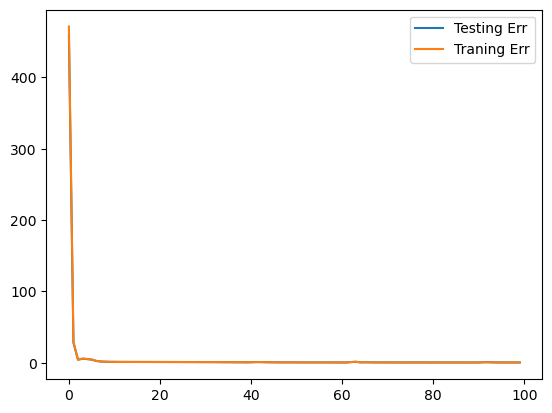

In [12]:
import matplotlib.pyplot as plt
print("MSE: %.2f" % best_mse)
print("RMSE: %.2f" % np.sqrt(best_mse))
plt.plot(history)
plt.legend(["Testing Err", "Traning Err"])
plt.show()